# 03 - Statistical Model (Prophet)
## Rossmann Store Sales Forecasting
Goal: fit a statistical time series model that explicitly captures trend, weekly/year seasonality, and promo/holiday effects, and see whether it beats the corrected baselines from notebook 02. </br>
**Recap - baselines to beat:**
| **Baseline** | **MAE** | **RMSE** | **MAPE** |
| --- | --- | --- | --- |
| Naive (lag-1) | 2119.7 | 3756.85 | 30.18% |
| **Seasonal naive (lag-7)** | 2178.00 | **2809.07** | 31.82% |
| Moving average (7-day) | 2873.68 | 3951.02 | 40.80% | 
| Moving average (28-day) | 2772.20 | 3852.91 | 39.04% |

Seasonal naive (lag-7) is the bar to clear, given it won on RMSE - the metric that matters most here since large misses are worse in practice than being consistently a bit off.</br>

**Scoping decision, stated upfront:** fitting a separate model per store across all 1,115 stores would be slow for casual-pace iteration. This notebook fits Prophet on a **sample of 20 stores**, chosen to span different store types, a deliberate, documented trade-off, not a shortcut being hidden. Baseline metrics are recomputed on this exact same 20-store subset below, so the comparison is geniunely apples-to-apples (the notebook 02 baseline numbers above were computed across all ~1000+ stores and aren't directly comparable to this notebook's without that adjustment).

In [1]:
import sys
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path('..') / "src"))
from eval_utils import save_result, load_results

sns.set_style('whitegrid')

## 1. Load the chronological train/test split
Reusing the exact split saved in notebook 02 - critical that Prophet is never fit on any date at or after the cutoff.

In [3]:
train_df = pd.read_csv("../data/processed/train.csv", parse_dates=['Date'])
test_df = pd.read_csv("../data/processed/test.csv", parse_dates=['Date'])

print('Train:', train_df.shape, 'Test:', test_df.shape)
print('Train max date:', train_df['Date'].max(), ' | Test min date:', test_df['Date'].min())

Train: (802996, 29) Test: (41396, 29)
Train max date: 2015-06-18 00:00:00  | Test min date: 2015-06-19 00:00:00


## 2. Sample stores for this notebook's scope
Stratifying by StoreType so the sample reflects the store-type variation found in EDA, rather than picking 20 stores at random and risking an unrepresentative sample

In [6]:
np.random.seed(42)
sampled_stores = (
    train_df[['Store', 'StoreType']]
    .drop_duplicates()
    .groupby('StoreType', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 5), random_state=42))
)['Store'].tolist()
print(f'Sampled {len(sampled_stores)} stores:', sampled_stores)

train_sample = train_df[train_df['Store'].isin(sampled_stores)].copy()
test_sample = test_df[test_df['Store'].isin(sampled_stores)].copy()
print(f'\nTrain sample: {train_sample.shape[0]:,} rows, Test sample: {test_sample.shape[0]:,} rows')

Sampled 20 stores: [195, 791, 1053, 138, 330, 85, 259, 353, 1081, 682, 1006, 464, 1070, 196, 852, 772, 347, 982, 806, 515]

Train sample: 15,287 rows, Test sample: 770 rows


/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_85246/3915997288.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 5), random_state=42))


## 3. Recompute baselines on this exact same store subset
For a fair comparison, the notebook 02 baseline numbers were computed across all stores, not this specific 20-store sample

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_metrics(y_true, y_pred):
    valid = ~(y_true.isna() | y_pred.isna())
    y_true, y_pred = y_true[valid], y_pred[valid]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    return mae, rmse, mape

baseline_mae, baseline_rmse, baseline_mape = compute_metrics(
    test_sample['Sales'], test_sample['Sales_lag_7']
)
print(f'Seasonal naive (lag-7), same 20-store subset:')
print(f'MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}, MAPE: {baseline_mape:.2f}%')

save_result('Seasonal naive (lag-7), 20-store subset', {
    'mae': round(baseline_mae, 2), 'rmse': round(baseline_rmse, 2), 'mape': round(baseline_mape, 2)
})

Seasonal naive (lag-7), same 20-store subset:
MAE: 2100.33, RMSE: 2615.50, MAPE: 28.57%


{'Naive (lag-1)': {'mae': 2119.17, 'rmse': 3756.85, 'mape': 30.18},
 'Seasonal naive (lag-7)': {'mae': 2178.0, 'rmse': 2809.07, 'mape': 31.82},
 'Moving average (7-day)': {'mae': 2873.68, 'rmse': 3951.02, 'mape': 40.8},
 'Moving average (28-day)': {'mae': 2772.2, 'rmse': 3852.91, 'mape': 39.04},
 'Seasonal naive (lag-7), 20-store subset': {'mae': np.float64(2100.33),
  'rmse': np.float64(2615.5),
  'mape': np.float64(28.57)}}

## 4. Fit Prophet per store
Prophet needs columns name exactly `ds` (date) and `y` (target). Adding `Promo` and `SchoolHoliday` as regressors, both are known in advance in real deployment (promotional calendars and school holidays are planned ahead in time, not random), so using them as forecast inputs is realistic, not a leak. `StateHoliday` is converted to a binary flag for the same reason.</br>

Prophet's built-in `weekly_seasonality` and `yearly_seasonality` handle the seasonality patterns found in EDA automatically - no need to manually engineer those the way the ML approach (notebook 04) will.

In [8]:
from prophet import Prophet

def fit_and_forecast(store_id, train_df, test_df):
    store_train = train_df[train_df['Store'] == store_id].copy()
    store_test = test_df[test_df['Store'] == store_id].copy()

    store_train['StateHoliday_flag'] = (store_train['StateHoliday'] != '0').astype(int)
    store_test['StateHoliday_flag'] = (store_test['StateHoliday'] != '0').astype(int)

    prophet_train = store_train.rename(columns={'Date': 'ds', 'Sales': 'y'})[
        ['ds', 'y', 'Promo', 'SchoolHoliday', 'StateHoliday_flag']
    ]

    model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    model.add_regressor('Promo')
    model.add_regressor('SchoolHoliday')
    model.add_regressor('StateHoliday_flag')
    model.fit(prophet_train)

    future = store_test.rename(columns={'Date': 'ds'})[
        ['ds', 'Promo', 'SchoolHoliday', 'StateHoliday_flag']
    ]
    forecast = model.predict(future)

    result = store_test[['Store', 'Date', 'Sales']].copy()
    result['Prophet_pred'] = forecast['yhat'].values
    return result, model
    

In [9]:
all_results = []
example_model = None #keep one fitted model around for the components plot

for i, store_id in enumerate(sampled_stores):
    result, model = fit_and_forecast(store_id, train_sample, test_sample)
    all_results.append(result)
    if i == 0:
        example_model = model
        example_store_id = store_id
    print(f'Fit store {store_id} ({i+1}/{len(sampled_stores)})')

prophet_results = pd.concat(all_results, ignore_index=True)
print(f'\nTotal predictions: {len(prophet_results):,}')

22:42:53 - cmdstanpy - INFO - Chain [1] start processing
22:42:53 - cmdstanpy - INFO - Chain [1] done processing
22:42:53 - cmdstanpy - INFO - Chain [1] start processing
22:42:53 - cmdstanpy - INFO - Chain [1] done processing
22:42:53 - cmdstanpy - INFO - Chain [1] start processing
22:42:53 - cmdstanpy - INFO - Chain [1] done processing


Fit store 195 (1/20)
Fit store 791 (2/20)
Fit store 1053 (3/20)


22:42:53 - cmdstanpy - INFO - Chain [1] start processing
22:42:53 - cmdstanpy - INFO - Chain [1] done processing
22:42:53 - cmdstanpy - INFO - Chain [1] start processing
22:42:53 - cmdstanpy - INFO - Chain [1] done processing
22:42:53 - cmdstanpy - INFO - Chain [1] start processing
22:42:54 - cmdstanpy - INFO - Chain [1] done processing


Fit store 138 (4/20)
Fit store 330 (5/20)
Fit store 85 (6/20)


22:42:54 - cmdstanpy - INFO - Chain [1] start processing
22:42:54 - cmdstanpy - INFO - Chain [1] done processing
22:42:54 - cmdstanpy - INFO - Chain [1] start processing
22:42:54 - cmdstanpy - INFO - Chain [1] done processing
22:42:54 - cmdstanpy - INFO - Chain [1] start processing
22:42:54 - cmdstanpy - INFO - Chain [1] done processing


...

Fit store 1070 (13/20)
Fit store 196 (14/20)
Fit store 852 (15/20)


22:42:54 - cmdstanpy - INFO - Chain [1] done processing
22:42:54 - cmdstanpy - INFO - Chain [1] start processing
22:42:54 - cmdstanpy - INFO - Chain [1] done processing
22:42:55 - cmdstanpy - INFO - Chain [1] start processing
22:42:55 - cmdstanpy - INFO - Chain [1] done processing
22:42:55 - cmdstanpy - INFO - Chain [1] start processing
22:42:55 - cmdstanpy - INFO - Chain [1] done processing


Fit store 772 (16/20)
Fit store 347 (17/20)
Fit store 982 (18/20)


22:42:55 - cmdstanpy - INFO - Chain [1] start processing
22:42:55 - cmdstanpy - INFO - Chain [1] done processing


Fit store 806 (19/20)
Fit store 515 (20/20)

Total predictions: 770


## 5. Evaluate Prophet against the baseline

In [10]:
prophet_mae, prophet_rmse, prophet_mape = compute_metrics(
    prophet_results['Sales'], prophet_results['Prophet_pred']
)
print(f'Prophet, 20-store subset:')
print(f'MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}, MAPE: {prophet_mape:.2f}%')

save_result('Prophet, 20-store subset', {
    'mae': round(prophet_mae, 2), 'rmse': round(prophet_rmse, 2), 'mape': round(prophet_mape, 2)
})

print(f'\nComparison:')
print(f'Seasonal naive (lag-7): MAE {baseline_mae:.2f}, RMSE {baseline_rmse:.2f}, MAPE {baseline_mape:.2f}%')
print(f'Prophet:               MAE {prophet_mae:.2f},   RMSE {prophet_rmse:.2f},  MAPE {prophet_mape:.2f}%')

Prophet, 20-store subset:
MAE: 1730.99, RMSE: 2475.17, MAPE: 22.58%

Comparison:
Seasonal naive (lag-7): MAE 2100.33, RMSE 2615.50, MAPE 28.57%
Prophet:               MAE 1730.99,   RMSE 2475.17,  MAPE 22.58%


Comparing the baseline lag-7 model and the Prophet model run on the 20-store subset, the Prophet model beat the baseline with a lower RMSE and MAPE

## 6. Visualize: actual vs. Prophet forecast for one store

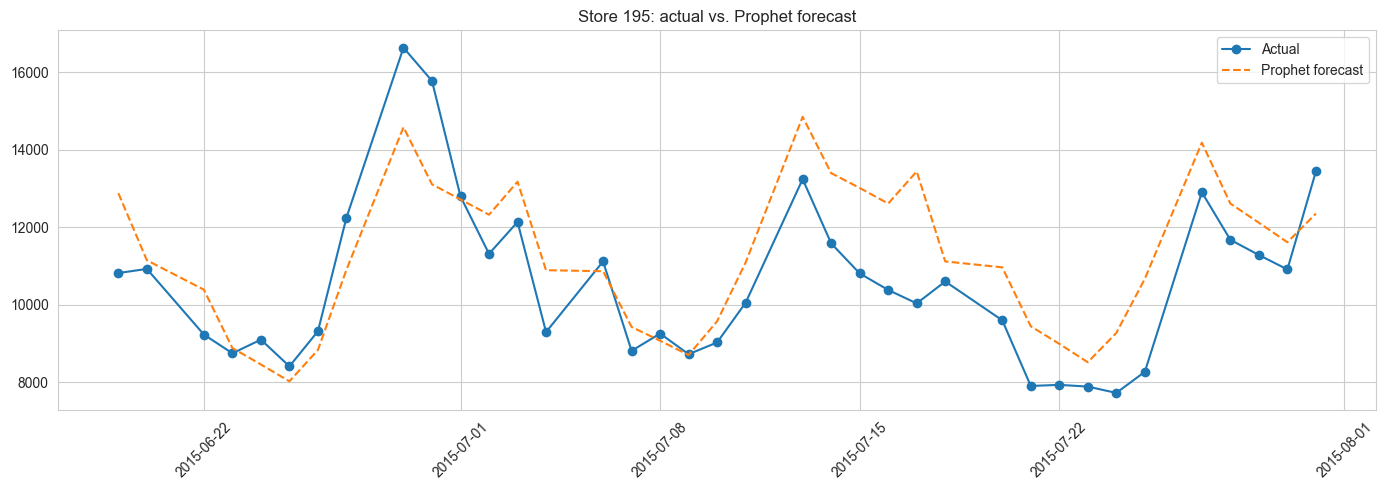

In [11]:
example_actual = prophet_results[prophet_results['Store'] == example_store_id]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(example_actual['Date'], example_actual['Sales'], label='Actual', marker='o')
ax.plot(example_actual['Date'], example_actual['Prophet_pred'], label='Prophet forecast', linestyle='--')
ax.set_title(f'Store {example_store_id}: actual vs. Prophet forecast')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Decompose the forecast - trend, weekly, and yearly components
This is Prophet's clearest advantage over a black-box ML model: you can directly see what it believes the trend, weekly pattern, and yearly pattern each look like, separately - useful both for sanity-checking the model and for explaining forecasts to a non-technical stakeholder

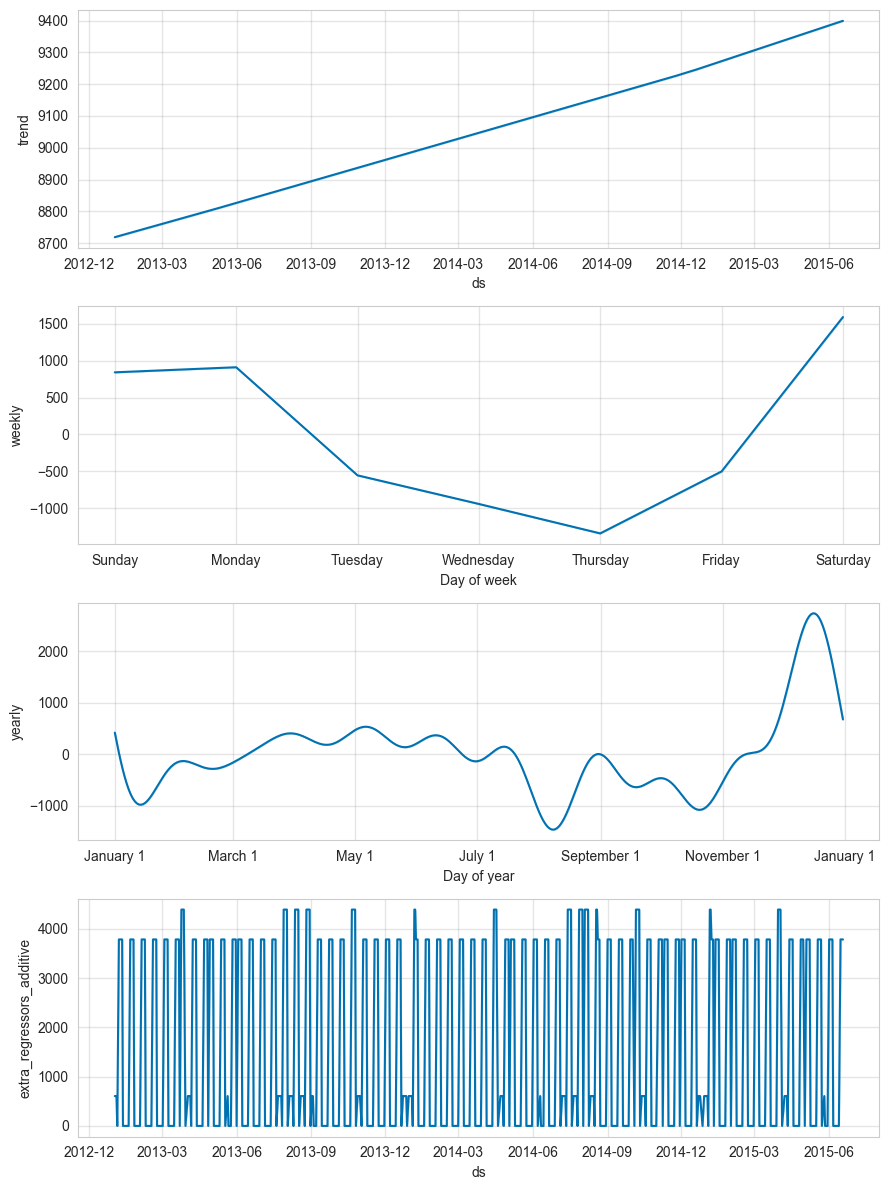

In [13]:
future_full = train_sample[train_sample['Store'] == example_store_id].rename(
        columns={'Date': 'ds', 'Sales': 'y'}
).copy()
future_full['StateHoliday_flag'] = (future_full['StateHoliday'] != '0').astype(int)

forecast_full = example_model.predict(
    future_full[['ds', 'Promo', 'SchoolHoliday', 'StateHoliday_flag']]
)

fig = example_model.plot_components(forecast_full)
plt.show()

The Prophet models shows us that over time sales increased linearly between the date range the data is in, the model also shows sales increase between Friday and Saturday (which is different from the EDA that showed sales increased on Mondays). The model also shows a clear bump in sales around the holiday season in December. The extra regressor additives are a bit too noisy to make a clear finding from currently

## 8. Summary
The Prophet model outperformed the seasonal naive lag-7 (on the 20-store subset)
| Model | MAE | RMSE | MAPE |
| --- | --- | --- | ---|
| Seasonal naive (lag-7) | 2100.33 | 2615.50 | 28.57% |
| Prophet | 1730.99 | 2475.17 | 22.58% |

The decomposition of the Prophet model shows us a linear increase in sales between 2012-2015, the weekly seasonality shows an increase in sales on Saturdays, and there's a clear increase in sales during the holiday season in December. The added complexity of the Prophet seems worth it here as the model didn't take too long to run (remembering it only used a 20-store sample). </br>

Next: `04_ml_xgboost_features.ipynb` - XGBoost with engineered lag, rolling, and date features, evaluated on the FULL test set (not just this 20-store sample); the fairest, most complete comparison.